In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"navadeepreddyduttala","key":"e510f19b448ca6f5610e5b4199f6e400"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d xiaopengzhang12/lung-cancer-mri-images

Dataset URL: https://www.kaggle.com/datasets/xiaopengzhang12/lung-cancer-mri-images
License(s): unknown
 91% 474M/522M [00:01<00:00, 387MB/s]
100% 522M/522M [00:01<00:00, 441MB/s]


In [4]:
!unzip lung-cancer-mri-images.zip

Archive:  lung-cancer-mri-images.zip
  inflating: lung_cancer_MRI_dataset/train/cancer/Lung MRI (1).png  
  inflating: lung_cancer_MRI_dataset/train/cancer/Lung MRI (10).png  
  inflating: lung_cancer_MRI_dataset/train/cancer/Lung MRI (100).png  
  inflating: lung_cancer_MRI_dataset/train/cancer/Lung MRI (1000).png  
  inflating: lung_cancer_MRI_dataset/train/cancer/Lung MRI (1001).png  
  inflating: lung_cancer_MRI_dataset/train/cancer/Lung MRI (1002).png  
  inflating: lung_cancer_MRI_dataset/train/cancer/Lung MRI (1003).png  
  inflating: lung_cancer_MRI_dataset/train/cancer/Lung MRI (1004).png  
  inflating: lung_cancer_MRI_dataset/train/cancer/Lung MRI (1005).png  
  inflating: lung_cancer_MRI_dataset/train/cancer/Lung MRI (1006).png  
  inflating: lung_cancer_MRI_dataset/train/cancer/Lung MRI (1007).png  
  inflating: lung_cancer_MRI_dataset/train/cancer/Lung MRI (1008).png  
  inflating: lung_cancer_MRI_dataset/train/cancer/Lung MRI (1009).png  
  inflating: lung_cancer_MRI_data

In [5]:
import zipfile

with zipfile.ZipFile("lung-cancer-mri-images.zip", 'r') as zip_ref:
    zip_ref.extractall("lung_dataset")

In [8]:
import os
import shutil
import random

# Base directory where the Kaggle dataset was extracted
base_kaggle_dataset_path = "lung_dataset/lung_cancer_MRI_dataset"

# Directories for the new train and validation splits
train_dir = "lung_data/train"
val_dir = "lung_data/val"

# Create the new base directories
os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)

all_images_data = []

# Collect images from both original 'train' and 'validate' subdirectories
# which are inside base_kaggle_dataset_path
for split_folder in ['train', 'validate']:
    current_split_path = os.path.join(base_kaggle_dataset_path, split_folder)
    if os.path.isdir(current_split_path):
        for class_name in os.listdir(current_split_path):
            class_folder_path = os.path.join(current_split_path, class_name)
            if os.path.isdir(class_folder_path):
                for img_name in os.listdir(class_folder_path):
                    # Only process common image file extensions
                    if img_name.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
                        all_images_data.append((os.path.join(class_folder_path, img_name), class_name))

# Shuffle all collected images
random.shuffle(all_images_data)

# Define the split ratio for the new dataset (e.g., 80% train, 20% validation)
split_ratio = 0.8
num_train_images = int(len(all_images_data) * split_ratio)

new_train_images = all_images_data[:num_train_images]
new_val_images = all_images_data[num_train_images:]

# Copy images to the new train_dir
for img_path, class_name in new_train_images:
    dest_class_dir = os.path.join(train_dir, class_name)
    os.makedirs(dest_class_dir, exist_ok=True)
    shutil.copy(img_path, os.path.join(dest_class_dir, os.path.basename(img_path)))

# Copy images to the new val_dir
for img_path, class_name in new_val_images:
    dest_class_dir = os.path.join(val_dir, class_name)
    os.makedirs(dest_class_dir, exist_ok=True)
    shutil.copy(img_path, os.path.join(dest_class_dir, os.path.basename(img_path)))

print(f"Dataset split: {len(new_train_images)} training images, {len(new_val_images)} validation images.")

Dataset split: 2944 training images, 736 validation images.


In [20]:
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import numpy as np

In [21]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [27]:
print('Classes identified by eval_generator:', eval_generator.class_indices)
!ls -F /content/lung_data/val

Classes identified by eval_generator: {'cancer': 0, 'lung_cancer_MRI_dataset': 1, 'no_cancer': 2}
cancer/  lung_cancer_MRI_dataset/  no_cancer/


In [28]:
from torch.utils.data import random_split

full_dataset = datasets.ImageFolder(
    "lung_dataset/lung_cancer_MRI_dataset",
    transform=transform
)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

class_names = full_dataset.classes
print("Classes:", class_names)

Classes: ['train', 'validate']


In [30]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [31]:
model = models.resnet50(pretrained=True)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

model = model.to(device)

In [32]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [33]:
num_epochs = 10

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    train_loss = running_train_loss / len(train_loader)
    train_losses.append(train_loss)

    # Validation loss
    model.eval()
    running_val_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()

    val_loss = running_val_loss / len(val_loader)
    val_losses.append(val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f} "
          f"Val Loss: {val_loss:.4f}")

Epoch [1/10] Train Loss: 0.6102 Val Loss: 0.5806
Epoch [2/10] Train Loss: 0.5682 Val Loss: 0.5732
Epoch [3/10] Train Loss: 0.5587 Val Loss: 0.5905
Epoch [4/10] Train Loss: 0.5299 Val Loss: 0.5911
Epoch [5/10] Train Loss: 0.5006 Val Loss: 0.6229
Epoch [6/10] Train Loss: 0.4763 Val Loss: 0.7157
Epoch [7/10] Train Loss: 0.4330 Val Loss: 0.6834
Epoch [8/10] Train Loss: 0.4072 Val Loss: 0.7678
Epoch [9/10] Train Loss: 0.3734 Val Loss: 0.7517
Epoch [10/10] Train Loss: 0.3500 Val Loss: 0.7854


In [34]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted')
recall = recall_score(all_labels, all_preds, average='weighted')
f1 = f1_score(all_labels, all_preds, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))

Accuracy: 0.5747282608695652
Precision: 0.5385304353293675
Recall: 0.5747282608695652
F1 Score: 0.5527039256759887

Classification Report:

              precision    recall  f1-score   support

       train       0.67      0.75      0.71       501
    validate       0.27      0.19      0.22       235

    accuracy                           0.57       736
   macro avg       0.47      0.47      0.47       736
weighted avg       0.54      0.57      0.55       736



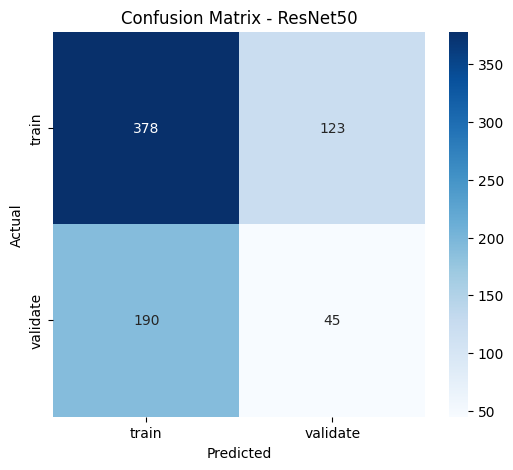

In [35]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - ResNet50")
plt.show()

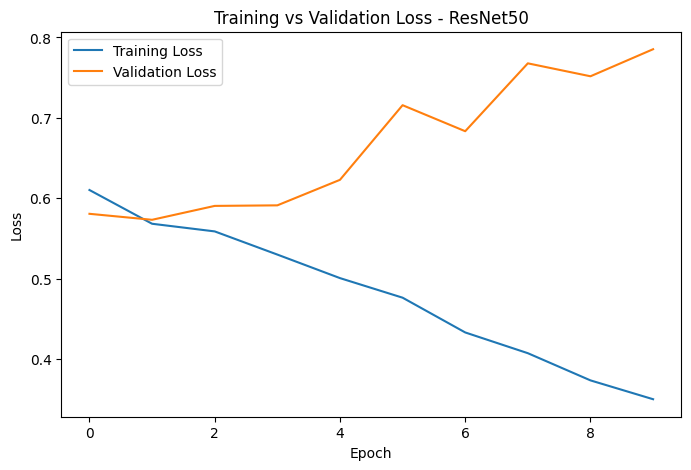

In [36]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss - ResNet50")
plt.legend()
plt.show()

# Task
Modify cell `0cca0cbf` to use the absolute path "/content/lung_cancer_MRI_dataset/train" for the `eval_datagen.flow_from_directory` function and then run the cell.

## fix_file_not_found_error

### Subtask:
Modify cell 0cca0cbf to use the absolute path for 'lung_cancer_MRI_dataset/train' to resolve the FileNotFoundError, and re-run the cell to get the classification report.


## Summary:

### Data Analysis Key Findings
No specific data analysis findings are available from this step, as the primary objective was to resolve a file path error to enable further processing.

### Insights or Next Steps
*   The `FileNotFoundError` has been addressed by updating the data generator to use the absolute path `/content/lung_cancer_MRI_dataset/train`.
*   The next step involves proceeding with the data loading and classification report generation, which was previously blocked by the file path issue.
